# Tecnicas de 

In [6]:
import os
print(os.getcwd())

c:\Curso Ciencia de Datos Talento Digital\clases grabadas\Clase 36


In [10]:
import pandas as pd 
data=pd.read_excel('cervezas.xlsx',index_col=None)
data

,Unnamed: 0,Name,Calories,Sodium,Alcohol,Cost
0,0,Budweiser,144,15,4.7,0.43
1,1,Schlitz,151,19,4.9,0.43
2,2,Lowenbrau,157,15,0.9,0.48
3,3,Kronenbourg,170,7,5.2,0.73
4,4,Heineken,152,11,5.0,0.77
5,5,Old_Milwaukee,145,23,4.6,0.28
6,6,Augsberger,175,24,5.5,0.40
7,7,Srohs_Bohemian_Style,149,27,4.7,0.42
8,8,Miller_Lite,99,10,4.3,0.43
9,9,Budweiser_Light,113,8,3.7,0.40


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  20 non-null     int64  
 1   Name        20 non-null     object 
 2   Calories    20 non-null     int64  
 3   Sodium      20 non-null     int64  
 4   Alcohol     20 non-null     float64
 5   Cost        20 non-null     float64
dtypes: float64(2), int64(3), object(1)
memory usage: 1.1+ KB


In [14]:
X=data[['Calories','Sodium','Alcohol','Cost']]
X.head()

,Calories,Sodium,Alcohol,Cost
0,144,15,4.7,0.43
1,151,19,4.9,0.43
2,157,15,0.9,0.48
3,170,7,5.2,0.73
4,152,11,5.0,0.77


In [15]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_scaled

array([[ 0.38791334,  0.00779468,  0.43380786, -0.45682969],
       [ 0.6250656 ,  0.63136906,  0.62241997, -0.45682969],
       [ 0.82833896,  0.00779468, -3.14982226, -0.10269815],
       [ 1.26876459, -1.23935408,  0.90533814,  1.66795955],
       [ 0.65894449, -0.6157797 ,  0.71672602,  1.95126478],
       [ 0.42179223,  1.25494344,  0.3395018 , -1.5192243 ],
       [ 1.43815906,  1.41083704,  1.1882563 , -0.66930861],
       [ 0.55730781,  1.87851782,  0.43380786, -0.52765599],
       [-1.1366369 , -0.7716733 ,  0.05658363, -0.45682969],
       [-0.66233238, -1.08346049, -0.5092527 , -0.66930861],
       [ 0.25239776,  0.47547547,  0.3395018 , -0.38600338],
       [-1.03500022,  0.00779468, -0.13202848, -0.24435076],
       [ 0.08300329, -0.6157797 , -0.03772242,  0.03895447],
       [ 0.59118671,  0.63136906,  0.43380786,  1.88043848],
       [ 0.55730781, -1.39524768,  0.71672602,  2.0929174 ],
       [-2.18688263,  0.00779468, -1.82953748, -0.81096123],
       [ 0.21851887,  0.

In [18]:
#Algoritmo jerarquico aglomerativo
from sklearn.cluster import AgglomerativeClustering
modelo=AgglomerativeClustering(n_clusters=4, metric='euclidean',linkage='ward')
modelo.fit(X_scaled)

,n_clusters,4
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [19]:
clusters=modelo.labels_
clusters

array([1, 1, 3, 2, 2, 1, 1, 1, 0, 0, 1, 0, 0, 2, 2, 0, 1, 1, 0, 0])

In [20]:
data['Cluster']=clusters
print(data)

    Unnamed: 0                  Name  Calories  Sodium  Alcohol  Cost  Cluster
0            0             Budweiser       144      15      4.7  0.43        1
1            1               Schlitz       151      19      4.9  0.43        1
2            2             Lowenbrau       157      15      0.9  0.48        3
3            3           Kronenbourg       170       7      5.2  0.73        2
4            4              Heineken       152      11      5.0  0.77        2
5            5         Old_Milwaukee       145      23      4.6  0.28        1
6            6            Augsberger       175      24      5.5  0.40        1
7            7  Srohs_Bohemian_Style       149      27      4.7  0.42        1
8            8           Miller_Lite        99      10      4.3  0.43        0
9            9       Budweiser_Light       113       8      3.7  0.40        0
10          10                 Coors       140      18      4.6  0.44        1
11          11           Coors_Light       102      

In [41]:
cluster_size=data.groupby('Cluster').size()
print(cluster_size  )

Cluster
0    7
1    8
2    4
3    1
dtype: int64


In [43]:
cluster_percent=data['Cluster'].value_counts(normalize=True)*100
cluster_percent

Cluster
1    40.0
0    35.0
2    20.0
3     5.0
Name: proportion, dtype: float64

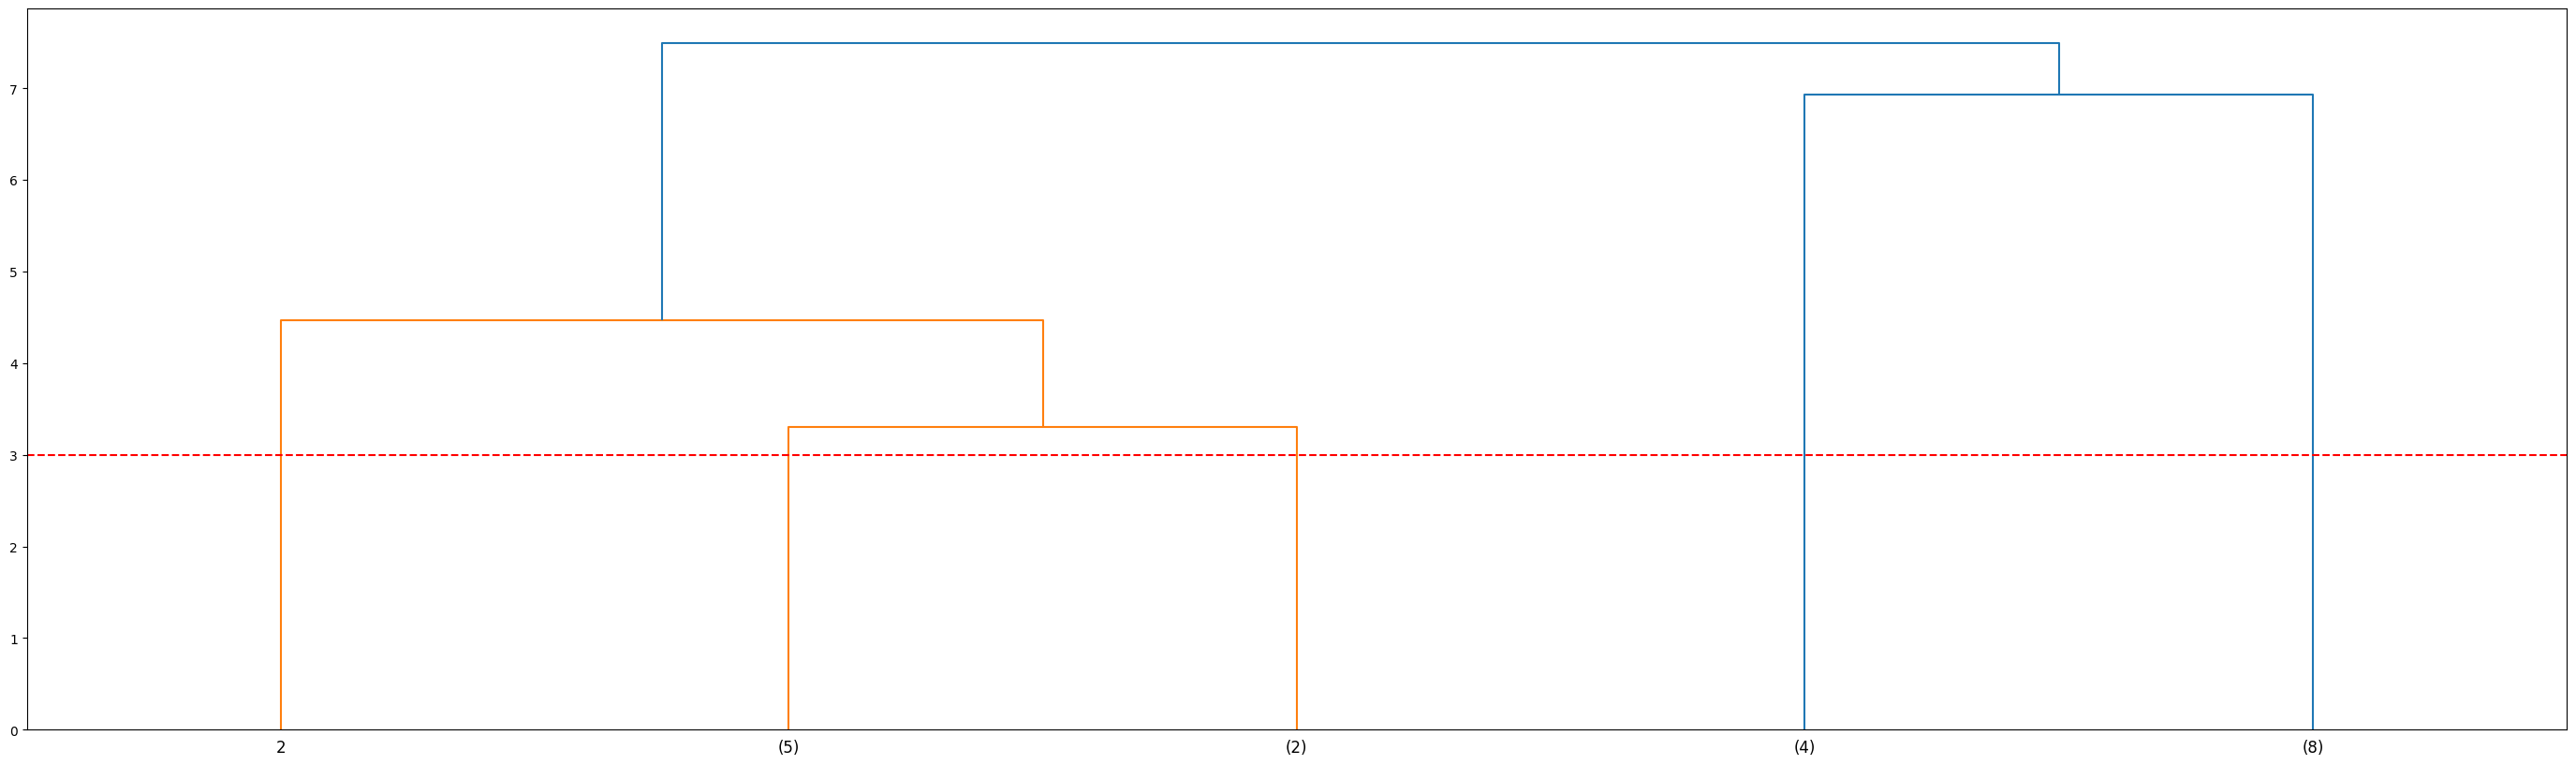

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z=linkage(X_scaled,method='ward')
plt.figure(figsize=(35,10))
dendrogram(Z,truncate_mode='lastp',p=5) #con p=5 definimos 5 clusters
plt.axhline(y=3,color='r',linestyle='--')

#fig=plt.figure(figsize=(25,10))
plt.show()

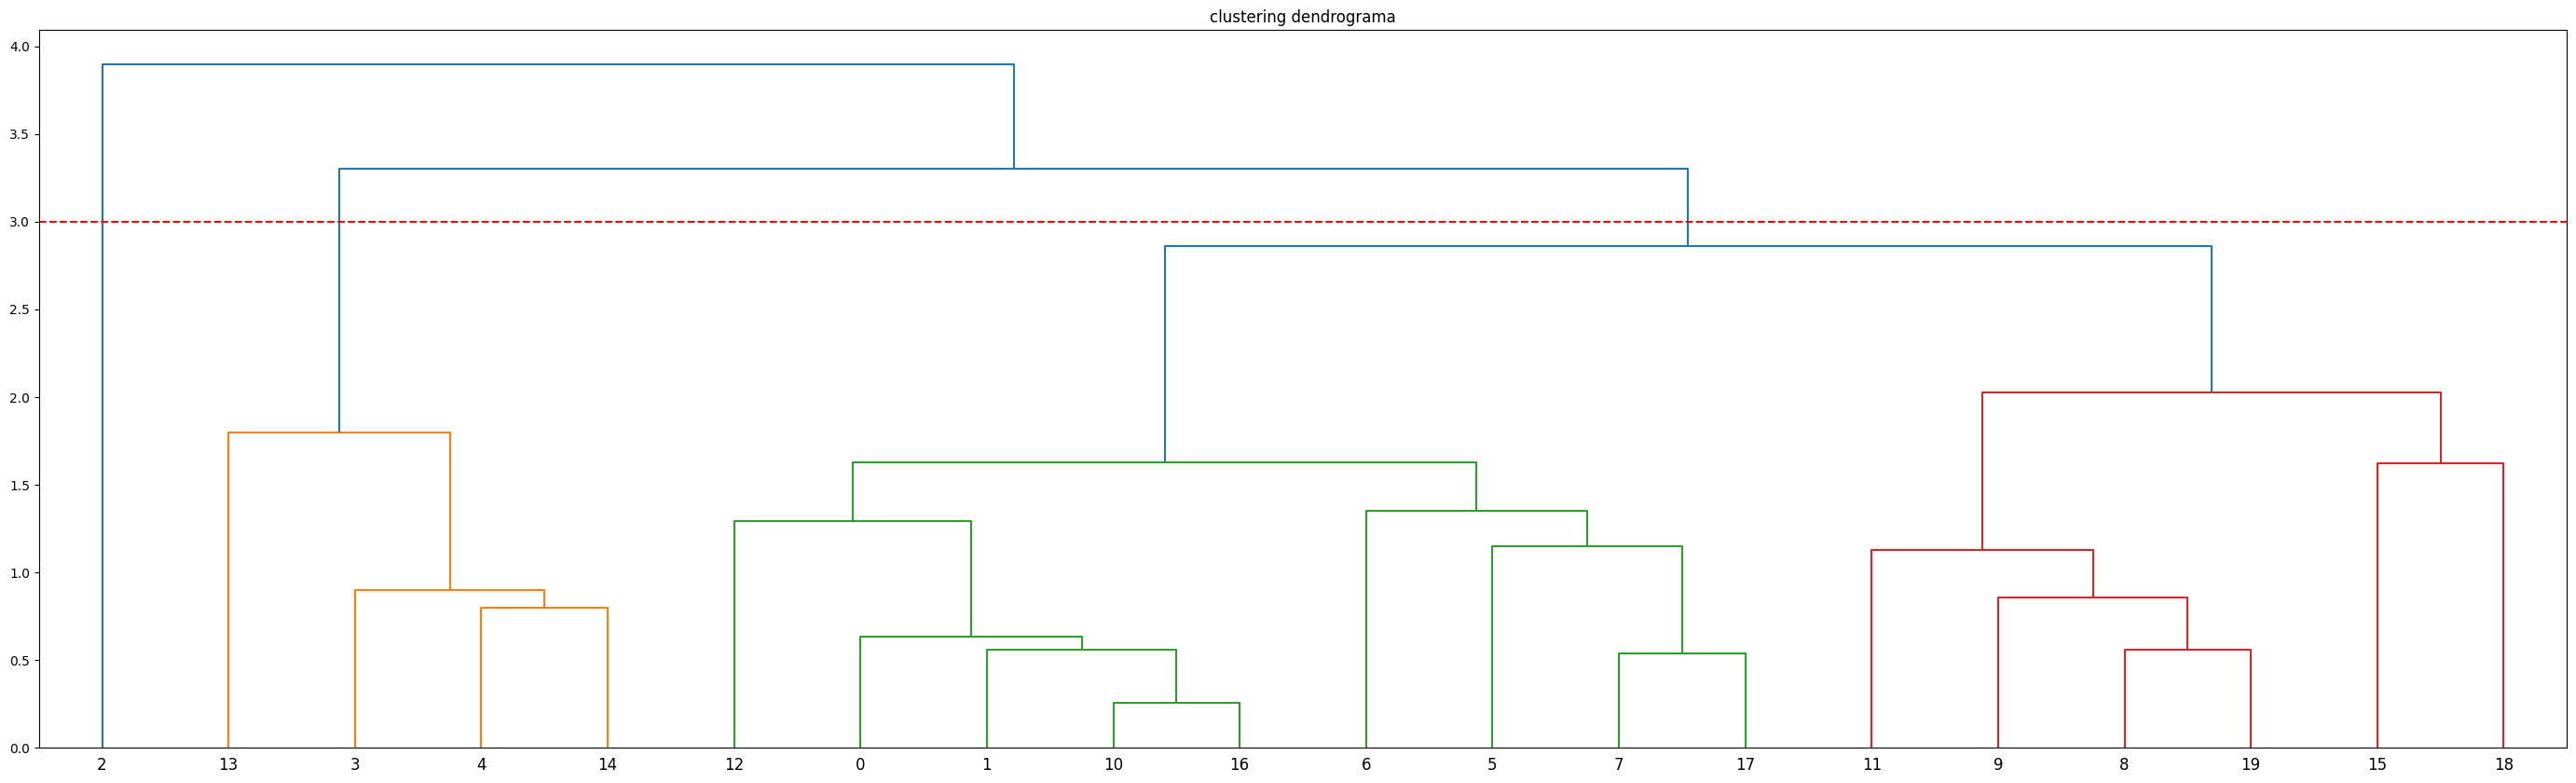

In [38]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z=linkage(X_scaled,method='average')
plt.figure(figsize=(35,10))
dendrogram(Z)
plt.axhline(y=3,color='r',linestyle='--')

plt.title('clustering dendrograma')
plt.show()

In [36]:
from sklearn.metrics import silhouette_score

for k in range(2,6):
    model=AgglomerativeClustering(n_clusters=k)
    labels=model.fit_predict(X_scaled)
    score=silhouette_score(X_scaled,labels)
    print(k,score)

2 0.31823936817062226
3 0.45777415910909475
4 0.47546412252215964
5 0.44406582701642483


In [ ]:
de estos resultados el mejor numeros de clusters es 4 porque encontramos el valor mayor del coeficiente de silhouette. que nos 
indica estructura moderada

coeficiente de silhuoette mide que tan bien separados y compactos estan los clusters. rango -1 a 1
mayor a 0.7 cluster muy bien definidos
0.5-0.7 buena separacion
0.25-0.5 estructura moderada
0- 0.25 cluster debiles o poco claros


In [ ]:
from scipy.cluster.hierarchy import fcluster
clusters=fcluster(Z,t=4,criterion='distance')

In [44]:
#perfiles de los cluster
cluster_profiling=data[['Calories', 'Sodium', 'Alcohol', 'Cost','Cluster']].groupby('Cluster').mean()
cluster_profiling

,Calories,Sodium,Alcohol,Cost
Cluster,,,,
0,98.000,10.285714,3.671429,0.442857
1,148.375,21.125000,4.787500,0.407500
2,155.250,10.750000,4.975000,0.762500
3,157.000,15.000000,0.900000,0.480000


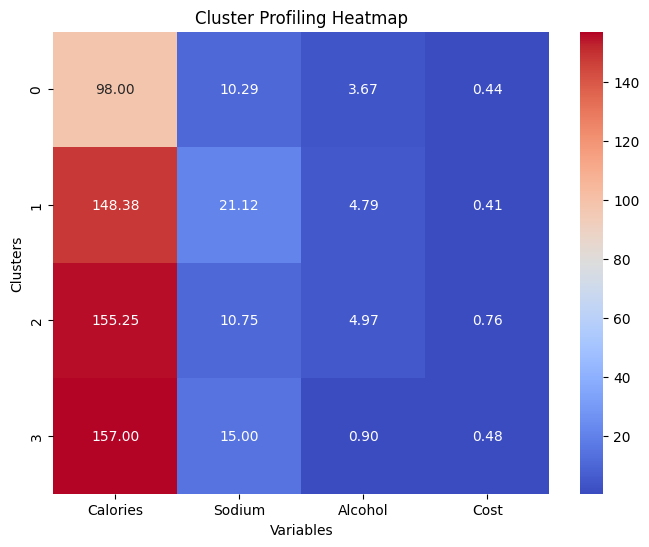

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    cluster_profiling,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Cluster Profiling Heatmap")
plt.xlabel("Variables")
plt.ylabel("Clusters")

plt.show()

En aprendizaje no supervisado, siempre hay que escalar los datos
ALGORITMOS:
* K-Means
* Jeranquico
* DBSCAN

Visualizacion:
* Scatter plots
* PCA
* t-SNE

Metricas evaluacion
* coef silouette-> da un rango -1,1 mas cercano a uno mayor separacion entre cluster, se muestra mejor la definicion de ellos
* indice Davies-bouldin
* indice Calinski-Harabasz